In [1]:
# ============================================================
# CELDA 1 — Importaciones
# ============================================================
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import glob
import os

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

In [2]:
# ============================================================
# CELDA 2 — Cargar datos de UNA cuerda específica
# ============================================================
ARCHIVO = "Longitudes/Cuerda1_L.csv"   # ← cambia aquí si quieres otra cuerda

df = pd.read_csv(ARCHIVO)

# Renombrar columnas para mayor comodidad
df.columns = ["Traste", "Inicio", "Final", "Longitud", "Frecuencia"]

print(df)

    Traste  Inicio  Final  Longitud  Frecuencia
0        0     0.0    0.0     65.00  330.331191
1        1     0.0    3.6     63.20  350.531976
2        2     3.6    7.0     59.70  373.100000
3        3     7.0   10.3     56.35  392.842768
4        4    10.3   13.3     53.20  415.391748
5        5    13.3   16.2     50.25  440.089661
6        6    16.2   19.0     47.40  466.049542
7        7    19.0   21.6     44.70  497.120900
8        8    21.6   24.0     42.20  526.785700
9        9    24.0   26.3     39.85  561.470500
10      10    26.3   28.5     37.60  594.967100
11      11    28.5   30.5     35.50  628.016200
12      12    30.5   32.4     33.55  665.044500
13      13    32.4   35.1     31.25  703.705500


In [3]:
# ============================================================
# CELDA 3 — Ajuste potencial (helper reutilizable)
# ============================================================
def ajuste_potencial(x, y):
    """
    Ajusta y = a * x^b usando regresión lineal en escala log-log.
    Retorna (a, b, R²).
    """
    log_x = np.log(x)
    log_y = np.log(y)
    coeffs = np.polyfit(log_x, log_y, 1)       # [b, log(a)]
    b = coeffs[0]
    a = np.exp(coeffs[1])

    # R² en escala original
    y_pred = a * x**b
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - ss_res / ss_tot

    return a, b, r2

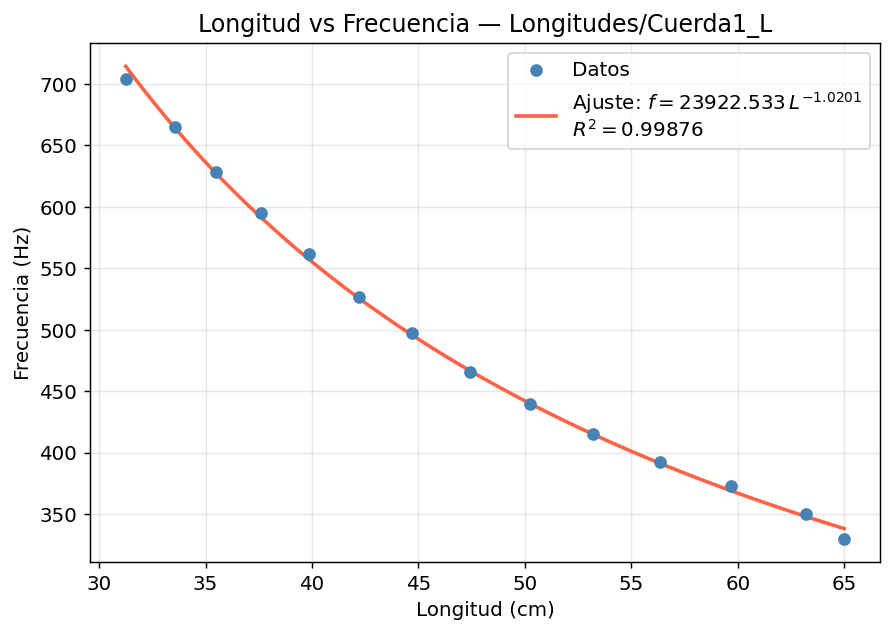

<Figure size 832x624 with 0 Axes>

In [4]:
# ============================================================
# CELDA 4 — Gráfica: Longitud vs Frecuencia (una cuerda)
# ============================================================
nombre_cuerda = os.path.splitext(ARCHIVO)[0]   # "Cuerda1_L"

x = df["Longitud"].values.astype(float)
y = df["Frecuencia"].values.astype(float)

a, b, r2 = ajuste_potencial(x, y)

x_fit = np.linspace(x.min(), x.max(), 300)
y_fit = a * x_fit**b

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(x, y, color="steelblue", zorder=3, label="Datos")
ax.plot(x_fit, y_fit, color="tomato", linewidth=2,
        label=f"Ajuste: $f = {a:.3f}\\,L^{{{b:.4f}}}$\n$R^2 = {r2:.5f}$")

ax.set_xlabel("Longitud (cm)")
ax.set_ylabel("Frecuencia (Hz)")
ax.set_title(f"Longitud vs Frecuencia — {nombre_cuerda}")
ax.legend()
plt.tight_layout()
plt.show()
plt.savefig(f"{nombre_cuerda}_LongitudVsFrecuencia.png", dpi=150)


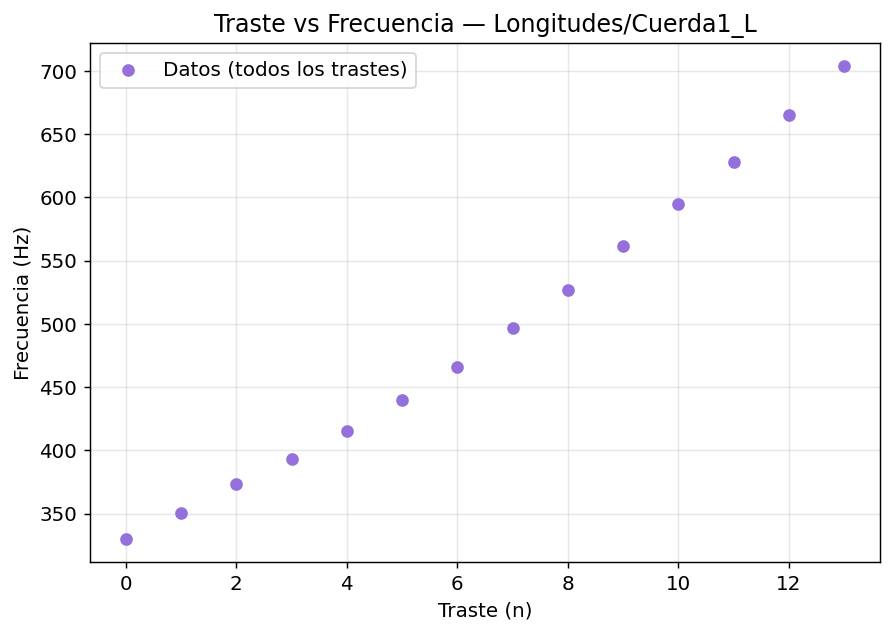

In [5]:
# ============================================================
# CELDA 5 — Gráfica: Traste vs Frecuencia (una cuerda)
# ============================================================

x_t = df["Traste"].values.astype(float)
y_t = df["Frecuencia"].values.astype(float)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(x_t, y_t,
           color="mediumpurple", zorder=3, label="Datos (todos los trastes)")

ax.set_xlabel("Traste (n)")
ax.set_ylabel("Frecuencia (Hz)")
ax.set_title(f"Traste vs Frecuencia — {nombre_cuerda}")
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# CELDA 6 — Cargar TODAS las cuerdas
#            (deben estar en el mismo directorio de trabajo)
# ============================================================
archivos = sorted(glob.glob("Longitudes/Cuerda*_L.csv"))
print(f"Archivos encontrados: {archivos}")

dfs = {}
for f in archivos:
    nombre = os.path.splitext(os.path.basename(f))[0]
    tmp = pd.read_csv(f)
    tmp.columns = ["Traste", "Inicio", "Final", "Longitud", "Frecuencia"]
    dfs[nombre] = tmp

print(f"\nTotal de cuerdas cargadas: {len(dfs)}")

Archivos encontrados: ['Longitudes/Cuerda1_L.csv', 'Longitudes/Cuerda2_L.csv', 'Longitudes/Cuerda3_L.csv', 'Longitudes/Cuerda4_L.csv', 'Longitudes/Cuerda5_L.csv', 'Longitudes/Cuerda6_L.csv']

Total de cuerdas cargadas: 6


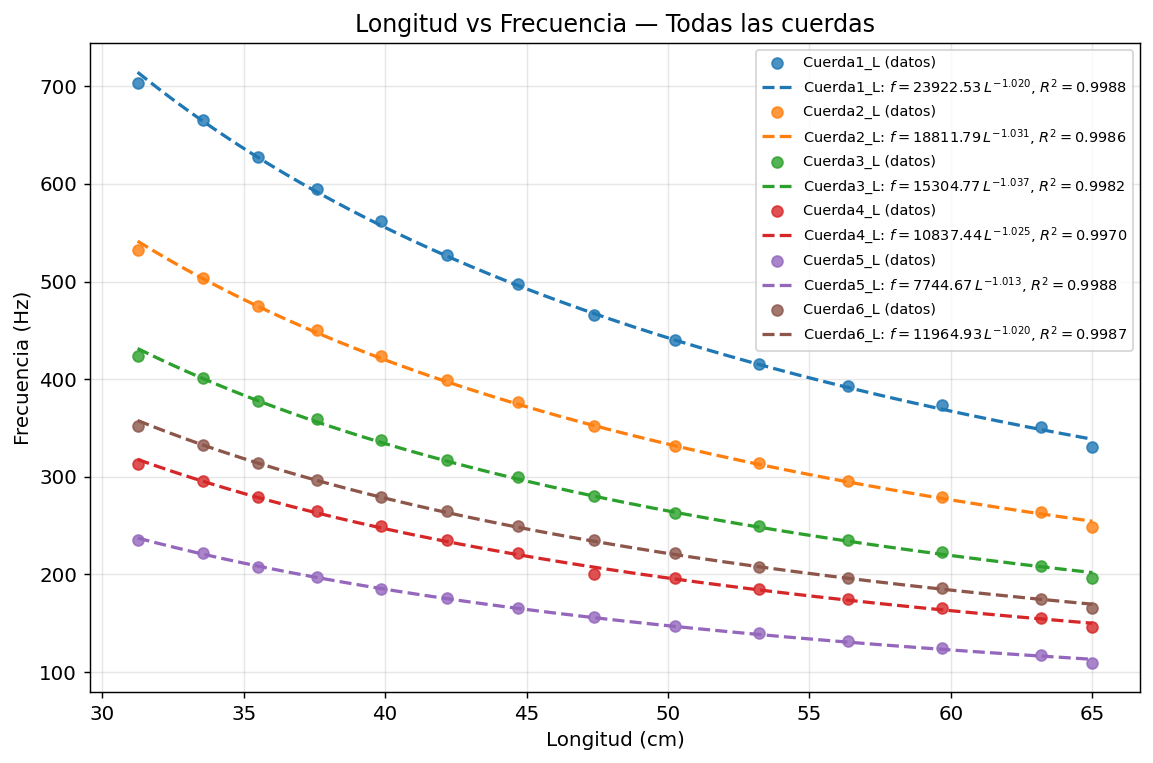

In [7]:
# ============================================================
# CELDA 7 — Gráfica combinada: Longitud vs Frecuencia (TODAS)
# ============================================================
colores = plt.cm.tab10.colors   # hasta 10 cuerdas con colores distintos

fig, ax = plt.subplots(figsize=(9, 6))

for i, (nombre, data) in enumerate(dfs.items()):
    color = colores[i % len(colores)]
    x = data["Longitud"].values.astype(float)
    y = data["Frecuencia"].values.astype(float)

    a, b, r2 = ajuste_potencial(x, y)
    x_fit = np.linspace(x.min(), x.max(), 300)

    ax.scatter(x, y, color=color, zorder=3, alpha=0.8, label=f"{nombre} (datos)")
    ax.plot(x_fit, a * x_fit**b, color=color, linewidth=1.8, linestyle="--",
            label=f"{nombre}: $f={a:.2f}\\,L^{{{b:.3f}}}$, $R^2={r2:.4f}$")

ax.set_xlabel("Longitud (cm)")
ax.set_ylabel("Frecuencia (Hz)")
ax.set_title("Longitud vs Frecuencia — Todas las cuerdas")
ax.legend(fontsize=8, loc="best")
plt.tight_layout()
plt.savefig("Todas_LongitudVsFrecuencia.png", dpi=150)
plt.show()

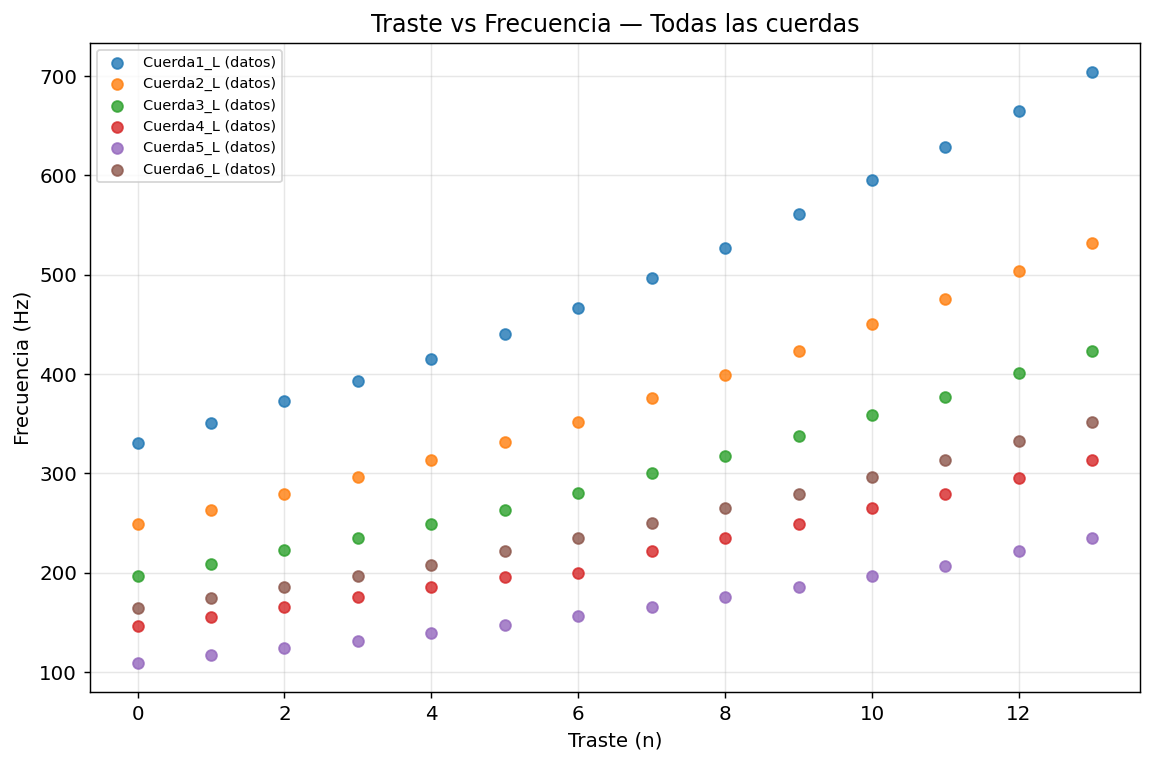

In [8]:
# ============================================================
# CELDA 8 — Gráfica combinada: Traste vs Frecuencia (TODAS)
# ============================================================
fig, ax = plt.subplots(figsize=(9, 6))

for i, (nombre, data) in enumerate(dfs.items()):
    color = colores[i % len(colores)]

    x_t = data["Traste"].values.astype(float)
    y_t = data["Frecuencia"].values.astype(float)

    ax.scatter(x_t, y_t,
               color=color, zorder=3, alpha=0.8, label=f"{nombre} (datos)")

ax.set_xlabel("Traste (n)")
ax.set_ylabel("Frecuencia (Hz)")
ax.set_title("Traste vs Frecuencia — Todas las cuerdas")
ax.legend(fontsize=8, loc="best")
plt.tight_layout()
plt.show()